# **Urban Water Demand Predcition with Climate Signals**

**Project Description** - This project focuses on predicting water consumption using deep learning models that incorporate climate variables such temperature, rainfall, wind speed.

**Gap Addressed** - Water demand is influenced by both weather conditions and human activity patterns, making accurate forecasting complex and challenging.

**Objectives** -

1.   Forecast water demand
2.   Integrate weather and climate data
3.   Support water resource planning


## **Exploratory Data Analysis**

In [ ]:
# import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the datasets
water_consumption_data = pd.read_csv("/content/water_ consumption_data.csv")
# rename the columns
# Date represents a timestamp
# Demand is the total water consumption on that date
water_consumption_data = water_consumption_data.rename(columns={"Consumption":"Demand"})
water_consumption_data.head()

,Date,Demand
0,1/7/2009,108637.2762
1,2/7/2009,108638.8474
2,3/7/2009,108633.8275
3,4/7/2009,109082.4222
4,5/7/2009,109071.7580


In [ ]:
# climate data
climate_data = pd.read_csv("/content/london_climate.csv")
climate_data.head()

,Date,Temp_Mean,Temp_Max,Temp_Min,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01 04:00:00,-5.543417,-2.883,-8.433001,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02 04:00:00,-2.745500,-0.633,-3.983000,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03 04:00:00,-1.049667,4.067,-4.033000,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04 04:00:00,1.317000,3.917,-5.633000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05 04:00:00,-12.037168,-6.483,-14.433001,0.000000,0.000000,29.598919,0.682800,7.04


In [ ]:
# re-create the date format
water_consumption_data["Date"] = pd.to_datetime(water_consumption_data["Date"], dayfirst=True)
# strip the time zone from climate dataset
climate_data["Date"] = pd.to_datetime(climate_data["Date"]).dt.normalize()
climate_data = climate_data.drop(columns=["Temp_Max", "Temp_Min"])

In [ ]:
# check null values - no null values
water_consumption_data.isnull().sum().sum()

np.int64(0)

In [ ]:
# no null values
climate_data.isnull().sum().sum()

np.int64(0)

In [ ]:
# merge two datasets on dates from 2015 Jan-2020 Sep
df = pd.merge(water_consumption_data,climate_data, on="Date",how="inner")
df.head()

,Date,Demand,Temp_Mean,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01,98343.49626,-5.543417,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02,98343.69374,-2.745500,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03,98684.73359,-1.049667,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04,98684.84818,1.317000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05,98685.22039,-12.037168,0.000000,0.000000,29.598919,0.682800,7.04


In [ ]:
df.dtypes # check data types

,0
Date,datetime64[ns]
Demand,float64
Temp_Mean,float64
Precipitation,float64
Rainfall,float64
Wind_Speed,float64
ET0,float64
Solar_Radiation,float64


In [ ]:
# summary statistics for all numeric columns
summary_stat = df.drop(columns=["Date"]).describe() # drop the date column
print(summary_stat)

              Demand    Temp_Mean  Precipitation     Rainfall   Wind_Speed  \
count    2004.000000  2004.000000    2004.000000  2004.000000  2004.000000   
mean   107978.285595     9.077903       2.781587     2.383333    19.486181   
std      9022.978383    10.803515       5.452121     5.330397     6.482443   
min     94995.010460   -22.166334       0.000000     0.000000     6.162207   
25%    100819.513525     0.324479       0.000000     0.000000    14.618837   
50%    104973.164650     9.141666       0.300000     0.000000    18.766664   
75%    114697.662250    19.127167       3.100000     1.900000    23.863409   
max    135780.426500    27.900337      51.699997    51.699997    50.975285   

               ET0  Solar_Radiation  
count  2004.000000      2004.000000  
mean      2.444930        14.179476  
std       1.725590         8.260710  
min       0.159680         0.730000  
25%       0.842876         6.897500  
50%       2.057534        13.405000  
75%       3.813426        21.04

The descriptive statistics reveal that the average daily water demand for the city is approximately 107,978 m3 across the study period from January 2015 to September 2021. The average daily temperature is around 9.1C and the rainfall is approximately 2.4 mm, while precipitation averages around 2.8 mm. The mean wind speed is around 19.5 kmh. These statistics provides an initial overview of the dataset.

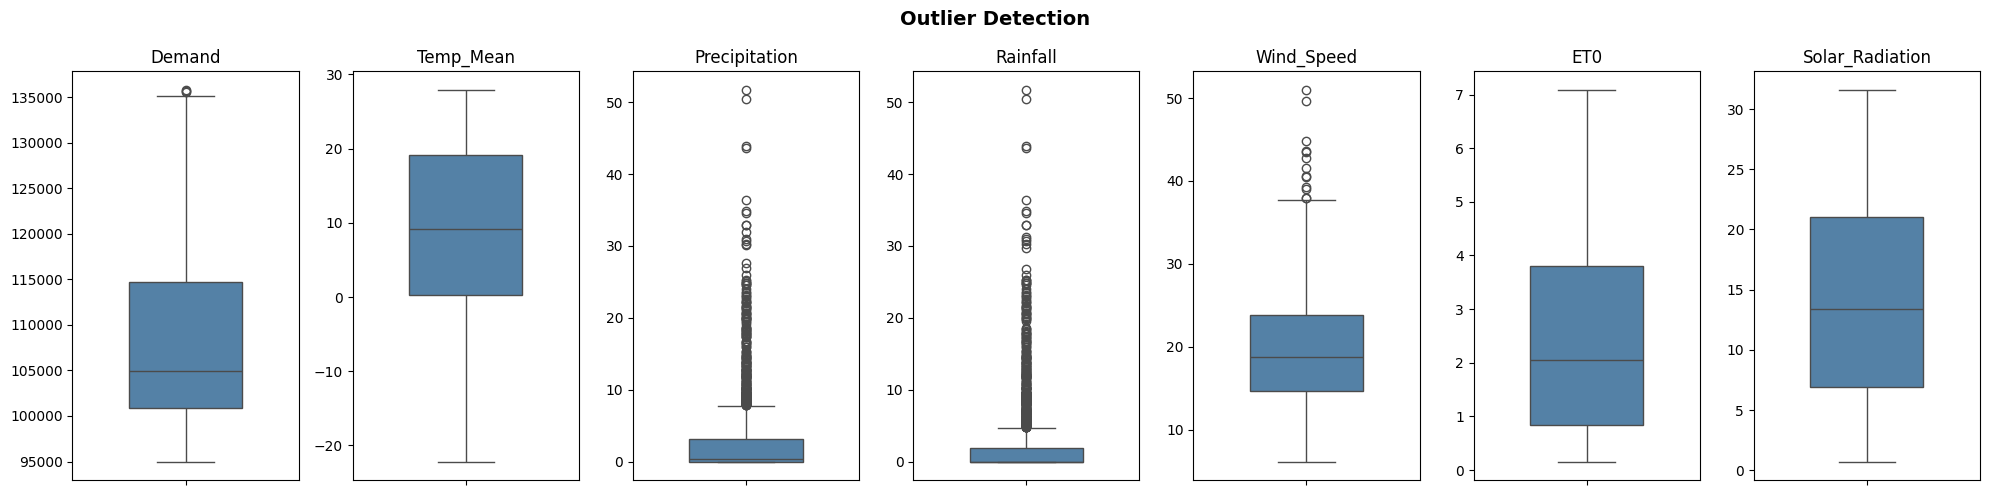

In [ ]:
# outlier detection (exclude date column)
df_1 = pd.DataFrame(df.drop(columns=["Date"]))
fig, axes = plt.subplots(1,7, figsize=(20,5))
axes = axes.flatten()

for i, col in enumerate(df_1.columns):
  sns.boxplot(y=df_1[col], ax=axes[i], color='steelblue', width=0.5)
  axes[i].set_title(f'{col}', fontsize=12)
  axes[i].set_ylabel('')
# give title
plt.suptitle("Outlier Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Outlier detecton is visulaised through box plots. Outliers were identified in precipitation, rainfall, wind speed variables. These outliers are remained as it is, becasue removing the anomalies would result in information loss or give negative impact to the model.

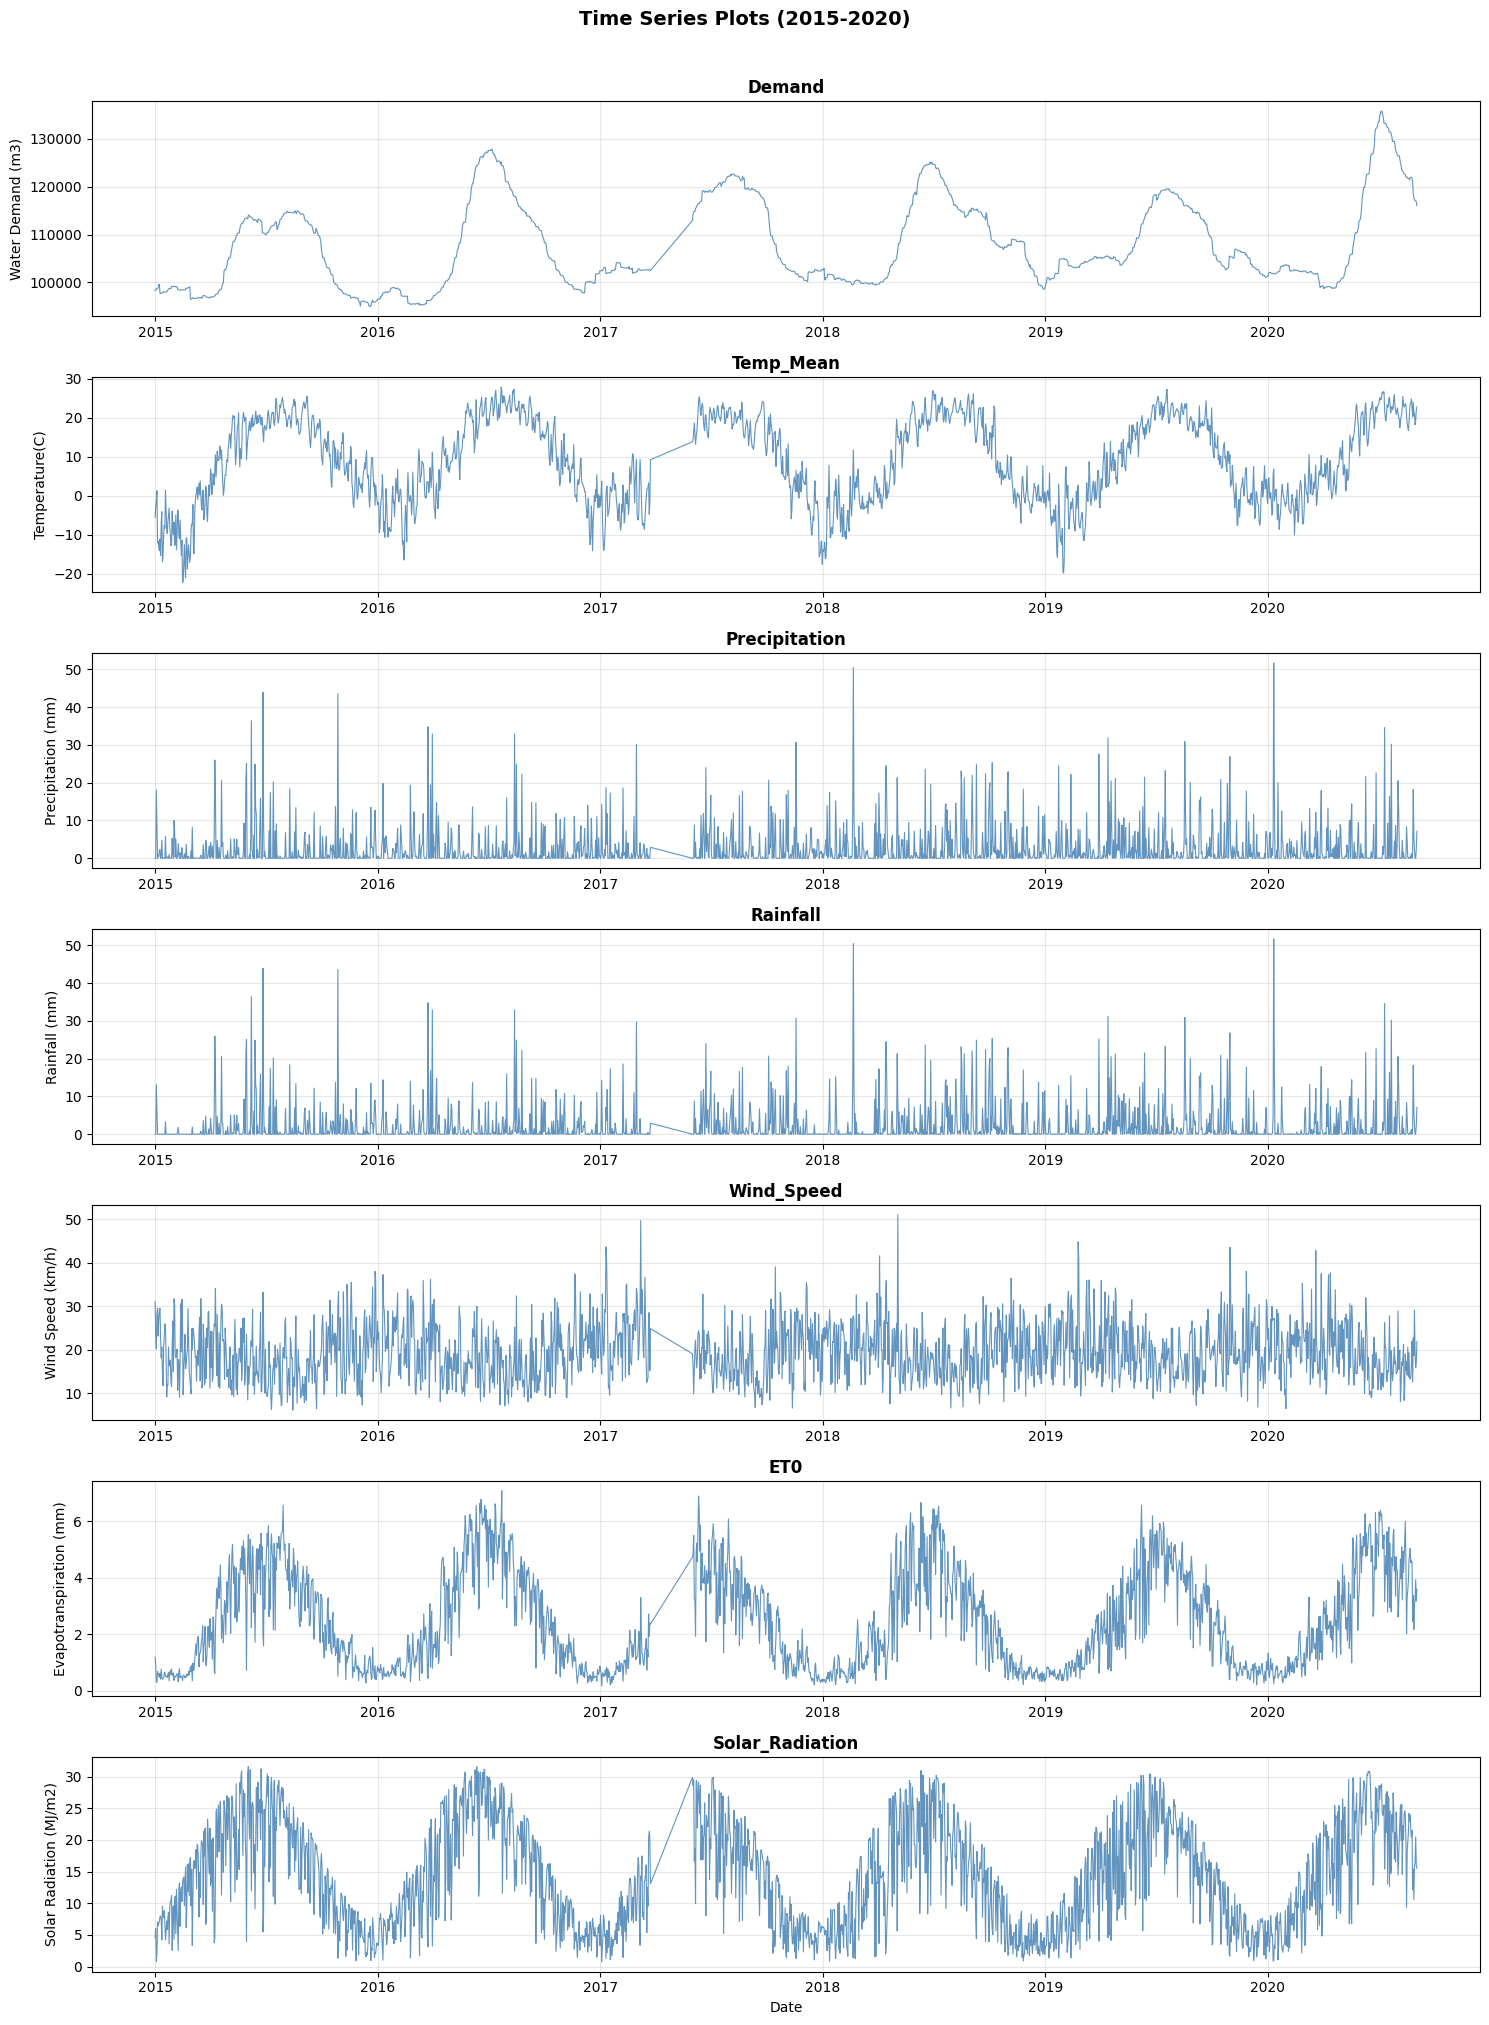

In [ ]:
# all the varaibles
variables = {
    'Demand' : 'Water Demand (m3)',
    'Temp_Mean' : 'Temperature(C)',
    'Precipitation' : 'Precipitation (mm)',
    'Rainfall' : 'Rainfall (mm)',
    'Wind_Speed' :'Wind Speed (km/h)',
    'ET0' : 'Evapotranspiration (mm)',
    'Solar_Radiation':'Solar Radiation (MJ/m2)'
}

fig, axes = plt.subplots(7,1, figsize= (15,20))
# create time series plots for all the variabels
for i,(col,label) in enumerate(variables.items()):
  axes[i].plot(df['Date'], df[col], color='steelblue', linewidth=0.8, alpha=0.85)
  axes[i].set_title(col, fontsize=12, fontweight='bold')
  axes[i].set_ylabel(label, fontsize=10)
  axes[i].set_xlabel('')
  axes[i].grid(True, alpha=0.3)

# show the date label on the bottom plot for visulization purposes
axes[-1].set_xlabel('Date', fontsize=10)
# give a title
plt.suptitle("Time Series Plots (2015-2020)", fontsize=14, fontweight='bold', y= 1.01)
plt.tight_layout()
plt.show()


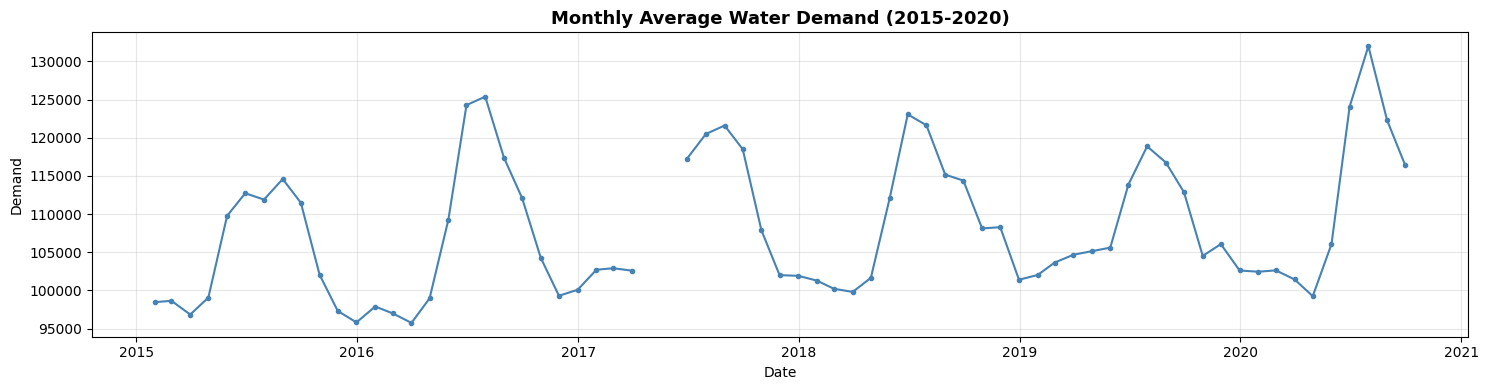

In [ ]:
# monthly data
# group data in time-based(monthly) and take the average demand
# resampling makes the index as Date column
# so reset the index
monthly = df.resample('ME', on='Date')['Demand'].mean().reset_index()

plt.figure(figsize = (15,4))
plt.plot(monthly['Date'], monthly['Demand'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.title('Monthly Average Water Demand (2015-2020)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the plots, water demand(consumption) tends to increase as the average temperature increases. Clear peaks are observed during the summer time (June-August) and the water demand is dropped in winter time(November-January). The same patterns repeats consistently across all years, indicating a strong seasonal influence on water demand. However, rainfall and percipitation don't shows a clear pattern, as the patterns don't follows the similar trend to water demand.

Water demand relatively peaks during the summer months, with the highest observed in 2021 and the second highest in 2016, which is ranging between 125,000 m3 - 135,000m3.  

There is a straight line connecting two data points around mid 2017, which is due to the dataset isn't covering the full year of 2017.

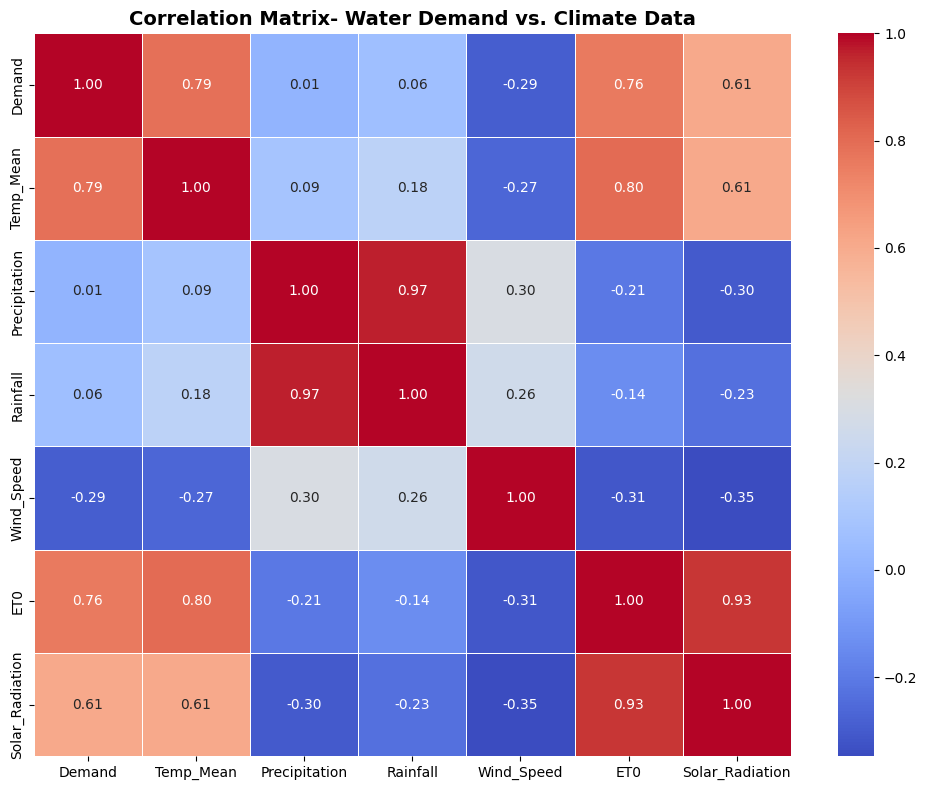

In [ ]:
# correlation matrix
correlation_matrix = df_1.corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix- Water Demand vs. Climate Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The Pearson correlation heatmap reveals the correltion between water demand and climate data. The average temperature shows the strongest positive correlation with water demand, which is 0.79. However, both percipitation and rainfall have low positive correlation, less than 0.1, indicating that the rainfall events have minimal influence on water demand variable. Wind speed shows moderate negative correlation, which is -0.29, meaning that higher wind speeds are associated with lower water demand. Overall based on this heatmap, we can say that the average temperature, ET0 and solar radiation are mainly associated with the water demand.  